## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO. SUBMIT A PDF THAT HAS THE WRITTEN ANSWERS WITH THIS COLAB**

(25 pts)

For our first homework assignment, we want you to perform the process of pre-preocessing data to use for training models. This is especially important in a multimodal setting, where you have several modalities that can be extracted from raw data.

Before we start directly processing data, let's think about a project objective or idea that you want to acheive with multimodal modeling/AI. This can range from anything, so be as creative as you want! Here are some questions to answer to help get you started:

1. What goal (or goals) do you want your model to do? An example would be predicting the genre of a movie, or analyzing sentiment from a video. We want you to think about and discuss what is the end goal of the project that you will end up implementing later in the course.
2. List out any datasets that you can find that can help accomplish this. Explain why you think the data is relevant and in addition discuss any drawbacks of the dataset.
3. What modalities do you choose to use? Why? Are there other modalities that could possibly be obtained that you don't plan on using? If so, why?
4. What difficulties did you encounter in obtaining the data?
5. Recall the [six core challenges of multimodal learning](https://arxiv.org/pdf/2209.03430). How do you plan on addressing them in your dataset or anticipate each of them impacting the way you design your dataset?


**Answer in separate writeup doc**

(20 pts)

We have provided a skeleton for you to start coding with, which contains an example of extracting frames of a video as images. Feel free to use this code as a starting point, but you are free to and encouraged to add more! The goal of this assignment (and what you will be graded on), is to extract a set of modalities from the dataset of your choice that is rich (in the sense that it would make sense to use/has valuable information) and contains unique information from other modalities.

**We strongly encourage that you take a good amount of time exploring and choosing the dataset you want to go with. The dataset/domain you decide to go with and the modalities you choose will be used for the rest of the HWs in this class. Create your dataset with this in mind!**

**You will submit a copy of this notebook with the code alongside your writeup. In your writeup, discuss the following:**


What difficulties did you encounter in extracting the modalities?  


**Answer in separate writeup doc**

In [ ]:
#!pip -q install -U datasets huggingface_hub

In [ ]:
#!pip install opencv-python

In [ ]:
from huggingface_hub import hf_hub_download
from datasets import load_dataset
import zipfile, os
import cv2
import os
import glob
import pandas as pd
import numpy as np
import re
import ast


from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt


In [ ]:
ds = load_dataset("lmms-lab/YouCook2")   # loads train/val from Hub
print(ds)
print(ds["val"][0])                      # inspect one sample
print(ds["val"].column_names)            # columns like id, video_url, segment, sentence, video_path, youtube_id


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/608 [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/168k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/43.7k [00:00<?, ?B/s]

Generating val split:   0%|          | 0/3179 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1471 [00:00<?, ? examples/s]

DatasetDict({
    val: Dataset({
        features: ['id', 'video_url', 'recipe_type', 'segment', 'sentence', 'video_path', 'youtube_id'],
        num_rows: 3179
    })
    test: Dataset({
        features: ['id', 'video_url', 'recipe_type', 'segment', 'sentence', 'video_path', 'youtube_id'],
        num_rows: 1471
    })
})
{'id': 'xHr8X2Wpmno_0', 'video_url': 'https://www.youtube.com/watch?v=xHr8X2Wpmno', 'recipe_type': '226', 'segment': [47.0, 60.0], 'sentence': 'pick the ends off the verdalago', 'video_path': 'val/xHr8X2Wpmno_0.mp4', 'youtube_id': 'xHr8X2Wpmno'}
['id', 'video_url', 'recipe_type', 'segment', 'sentence', 'video_path', 'youtube_id']


In [ ]:
all_parts = []
for split_name, split_ds in ds.items():
    df = split_ds.to_pandas()
    df["split"] = split_name
    all_parts.append(df)

all_df = pd.concat(all_parts, ignore_index=True)
train_df = all_df[all_df["split"] == "val"].copy()
test_df = all_df[all_df["split"] == "test"].copy()

all_df.to_csv("/content/youcook2_all_splits.csv", index=False)
train_df.to_csv("/content/youcook2_train_splits.csv", index=False)
test_df.to_csv("/content/youcook2_test_splits.csv", index=False)

print("Shape:", all_df.shape)
print("Columns:", list(all_df.columns))
display(all_df.head(3))

Shape: (4650, 8)
Columns: ['id', 'video_url', 'recipe_type', 'segment', 'sentence', 'video_path', 'youtube_id', 'split']


,id,video_url,recipe_type,segment,sentence,video_path,youtube_id,split
0,xHr8X2Wpmno_0,https://www.youtube.com/watch?v=xHr8X2Wpmno,226,"[47.0, 60.0]",pick the ends off the verdalago,val/xHr8X2Wpmno_0.mp4,xHr8X2Wpmno,val
1,xHr8X2Wpmno_1,https://www.youtube.com/watch?v=xHr8X2Wpmno,226,"[67.0, 89.0]",combine lemon juice sumac garlic salt and oil ...,val/xHr8X2Wpmno_1.mp4,xHr8X2Wpmno,val
2,xHr8X2Wpmno_2,https://www.youtube.com/watch?v=xHr8X2Wpmno,226,"[91.0, 98.0]",chop lettuce and place it in a bowl,val/xHr8X2Wpmno_2.mp4,xHr8X2Wpmno,val


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extract the videos from the hugging face
zip_path = hf_hub_download(
    repo_id="lmms-lab/YouCook2",
    repo_type="dataset",
    filename="YouCookIIVideos.zip"
)

extract_dir = "/content/youcook2_videos"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

print("Extracted to:", extract_dir)

YouCookIIVideos.zip:   0%|          | 0.00/7.35G [00:00<?, ?B/s]

Extracted to: /content/youcook2_videos


In [ ]:
candidates = glob.glob("/content/youcook2_videos/**/*.mp4", recursive=True)

video_path = candidates[0] # /content/youcook2_videos/val/some_video.mp4"

# set output_dir
output_dir = "/content/extracted_frames"
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
save_every_n_frames = 1

frame_count = 0
saved_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % save_every_n_frames == 0:
        frame_filename = os.path.join(output_dir, f"frame_{saved_count:05d}.jpg")
        cv2.imwrite(frame_filename, frame)
        # print(frame_filename)  # if want per-frame logs
        saved_count += 1

    frame_count += 1

cap.release()

print(f"Video: {video_path}")
print(f"Total frames read: {frame_count}")
print(f"Frames saved: {saved_count}")
print(f"Completed extracting frames to: {output_dir}")


Video: /content/youcook2_videos/YouCookIIVideos/val/DBgap0YANhs_4.mp4
Total frames read: 375
Frames saved: 375
Completed extracting frames to: /content/extracted_frames


In [ ]:
CSV_PATH = "/content/youcook2_train_splits.csv"
VIDEO_ROOT = "/content/youcook2_videos/YouCookIIVideos"
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
df.head(5)

Shape: (3179, 8)
Columns: ['id', 'video_url', 'recipe_type', 'segment', 'sentence', 'video_path', 'youtube_id', 'split']


,id,video_url,recipe_type,segment,sentence,video_path,youtube_id,split
0,xHr8X2Wpmno_0,https://www.youtube.com/watch?v=xHr8X2Wpmno,226,[47. 60.],pick the ends off the verdalago,val/xHr8X2Wpmno_0.mp4,xHr8X2Wpmno,val
1,xHr8X2Wpmno_1,https://www.youtube.com/watch?v=xHr8X2Wpmno,226,[67. 89.],combine lemon juice sumac garlic salt and oil ...,val/xHr8X2Wpmno_1.mp4,xHr8X2Wpmno,val
2,xHr8X2Wpmno_2,https://www.youtube.com/watch?v=xHr8X2Wpmno,226,[91. 98.],chop lettuce and place it in a bowl,val/xHr8X2Wpmno_2.mp4,xHr8X2Wpmno,val
3,xHr8X2Wpmno_3,https://www.youtube.com/watch?v=xHr8X2Wpmno,226,[ 99. 137.],add verdalago pepper cucumbers tomatoes herbs ...,val/xHr8X2Wpmno_3.mp4,xHr8X2Wpmno,val
4,xHr8X2Wpmno_4,https://www.youtube.com/watch?v=xHr8X2Wpmno,226,[153. 162.],pour the dressing over the salad and mix,val/xHr8X2Wpmno_4.mp4,xHr8X2Wpmno,val


num unique recipe types: 89
min to max: 101 425


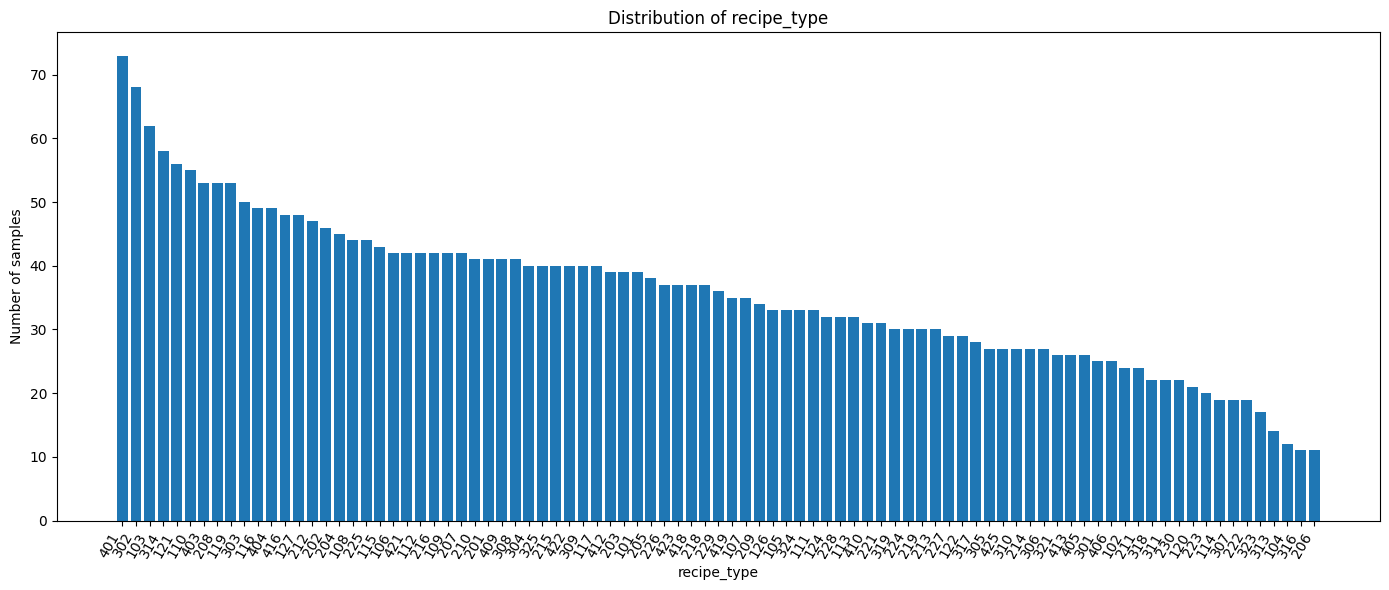

In [ ]:
recipe_counts = (
    df["recipe_type"]
    .fillna("unknown")
    .astype(str)
    .value_counts()
    .sort_values(ascending=False)
)

num_recipes = df["recipe_type"].astype(str).nunique()
print("num unique recipe types:", num_recipes)
print('min to max:', df["recipe_type"].min(), df["recipe_type"].max())

plt.figure(figsize=(14, 6))
plt.bar(recipe_counts.index, recipe_counts.values)
plt.title("Distribution of recipe_type")
plt.xlabel("recipe_type")
plt.ylabel("Number of samples")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
def frame_feature_bgr(frame, hist_bins=16):
    """
    Fast handcrafted frame descriptor:
    - RGB histogram (3 * hist_bins)
    - edge density (1)
    Total dim = 3*hist_bins + 1
    """
    # resize for consistency/speed
    frame = cv2.resize(frame, (224, 224), interpolation=cv2.INTER_AREA)

    # color hist in B,G,R
    feats = []
    for ch in range(3):
        h = cv2.calcHist([frame], [ch], None, [hist_bins], [0, 256]).flatten()
        h = h / (h.sum() + 1e-8)
        feats.append(h)
    feats = np.concatenate(feats, axis=0)

    # edge density
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    edge_density = edges.mean() / 255.0

    return np.concatenate([feats, np.array([edge_density], dtype=np.float32)], axis=0)


def extract_segment_video_feature(video_file,seg_start,seg_end,num_frames=8,hist_bins=16,fallback_whole_video=True):
    """
    Extracts fixed-length feature for one sample by:
      1) sampling num_frames in [seg_start, seg_end]
      2) frame feature per sample
      3) mean + std pooling over frames
    Output dim = 2 * (3*hist_bins + 1)
    """
    cap = cv2.VideoCapture(video_file)
    if not cap.isOpened():
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps is None or fps <= 0 or n_total <= 0:
        cap.release()
        return None

    video_dur = n_total / fps

    # sanitize segment
    if np.isnan(seg_start) or np.isnan(seg_end) or seg_end <= seg_start:
        if fallback_whole_video:
            seg_start, seg_end = 0.0, video_dur
        else:
            cap.release()
            return None

    seg_start = max(0.0, min(seg_start, video_dur))
    seg_end   = max(0.0, min(seg_end, video_dur))
    if seg_end <= seg_start:
        if fallback_whole_video:
            seg_start, seg_end = 0.0, video_dur
        else:
            cap.release()
            return None

    # sample timestamps uniformly
    ts = np.linspace(seg_start, seg_end, num=num_frames, endpoint=False)
    frame_feats = []

    for t in ts:
        frame_idx = int(t * fps)
        frame_idx = max(0, min(frame_idx, n_total - 1))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if not ok or frame is None:
            continue
        f = frame_feature_bgr(frame, hist_bins=hist_bins)
        frame_feats.append(f)

    cap.release()

    if len(frame_feats) == 0:
        return None

    F = np.vstack(frame_feats)
    mean_f = F.mean(axis=0)
    std_f = F.std(axis=0)
    return np.concatenate([mean_f, std_f], axis=0).astype(np.float32)


In [ ]:
def parse_segment(seg):
    """
    Parse segment values like '[47. 60.]', '[ 99. 137.]'
    Returns (start, end) as floats.
    """
    nums = re.findall(r"[-+]?\d*\.?\d+", seg)
    if len(nums) >= 2:
      return float(nums[0]), float(nums[1])

    return np.nan, np.nan


def add_temporal_features(df):
    """
    Adds:
      seg_start, seg_end, seg_duration, seg_mid
    """
    starts, ends = [], []
    for s in df["segment"].values:
        st, en = parse_segment(s)
        starts.append(st)
        ends.append(en)

    out = df.copy()
    out["seg_start"] = starts
    out["seg_end"] = ends
    out["seg_duration"] = out["seg_end"] - out["seg_start"]
    out["seg_mid"] = (out["seg_start"] + out["seg_end"]) / 2.0

    # drop any empty values
    out = out.dropna(subset=["seg_start", "seg_end", "seg_duration", "seg_mid"]).reset_index(drop=True)
    return out

In [ ]:
def build_video_features_from_files(df,video_root=VIDEO_ROOT, num_frames=8,hist_bins=16,verbose_every=200):
    """
    Returns:
      X_video: np.ndarray [N_valid, D]
      keep_idx: indices from original df that succeeded
      missing_count: how many failed
    """
    X = []
    keep_idx = []
    missing = 0

    for i, row in df.iterrows():
        if verbose_every and (i % verbose_every == 0):
            print(f"[video feats] processing {i}/{len(df)}")

        rel_path = str(row["video_path"]).strip()
        vf = os.path.join(video_root, rel_path)

        if not os.path.exists(vf):
            missing += 1
            continue

        seg_start, seg_end = parse_segment(row["segment"])

        feat = extract_segment_video_feature(
            vf, seg_start, seg_end, num_frames=num_frames, hist_bins=hist_bins
        )
        if feat is None:
            missing += 1
            continue

        X.append(feat)
        keep_idx.append(i)

    if len(X) == 0:
        raise RuntimeError("No video features extracted. Check VIDEO_ROOT and file naming.")

    X_video = np.vstack(X)
    return X_video, keep_idx, missing


In [ ]:
def build_text_embeddings(df, text_col="sentence", model_name="all-MiniLM-L6-v2"):
    model = SentenceTransformer(model_name)
    texts = df[text_col].fillna("").astype(str).tolist()
    X_text = model.encode(texts, convert_to_numpy=True, show_progress_bar=True)
    return X_text


def build_multimodal_features(X_text, X_video, alpha_text=1.0, alpha_video=1.0):
    """
    Concatenate normalized text + video features.
    """
    Xt = StandardScaler().fit_transform(X_text) * alpha_text
    Xv = StandardScaler().fit_transform(X_video) * alpha_video
    return np.concatenate([Xt, Xv], axis=1)

(15 pts)

As part of this assignment, we will look into visualizing you dataset in three parts:

1. Visualizing Data Distribution
2. Viualizing Samples
3. Visualizing Input Distribution

We have provided scripts that these visualizations using [t-SNE](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding) (t-distributed stochastic neighbor embedding). Your goal is to use these to visualize each of these for your dataset and include the visualziations in your submission. You will likely need to adjust the hyperparameters for the tsne model.

**Modify the functions to try different ways to visualize the dataset. Use differenrt distributions, visualizations, etc. Be creative! In the write up, discuss what visualizations you tried, why, and submit what the visualizations looked like.**

In [ ]:
def tsne_2d(X, perplexity=30, max_iter=1500, random_state=42, pca_first=50):
    Xs = StandardScaler().fit_transform(X)

    pca_dim = min(pca_first, Xs.shape[1], Xs.shape[0]-1)
    print('pca_dim=', pca_dim)
    if pca_dim >= 2:
        Xp = PCA(n_components=pca_dim, random_state=random_state).fit_transform(Xs)
    else:
        Xp = Xs

    perpl = min(perplexity, max(5, (len(Xp)-1)//3))

    Z = TSNE(
        n_components=2,
        perplexity=perpl,
        max_iter=max_iter,
        init="pca",
        learning_rate="auto",
        random_state=random_state
    ).fit_transform(Xp)
    return Z


def plot_tsne(Z, labels=None, title="t-SNE"):
    plt.figure(figsize=(8, 6))

    if labels is None:
        plt.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.8)
    else:
        s = pd.Series(labels)
        if pd.api.types.is_numeric_dtype(s):
            sc = plt.scatter(Z[:, 0], Z[:, 1], c=s.values, cmap="viridis", s=10, alpha=0.8)
            plt.colorbar(sc, label="value")
        else:
            cats = s.astype(str).values
            for c in np.unique(cats):
                idx = (cats == c)
                plt.scatter(Z[idx, 0], Z[idx, 1], s=10, alpha=0.75, label=c)
            plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()


In [ ]:
def visualize_samples(df, n=12, random_state=7):
    samp = df.sample(n, random_state=random_state).copy()
    display(samp[["id", "split", "recipe_type", "sentence", "segment", "video_path", "video_url"]])

    segs = samp["segment"].apply(parse_segment)
    starts = segs.apply(lambda x: x[0]).values
    ends = segs.apply(lambda x: x[1]).values

    plt.figure(figsize=(10, 6))
    for i, (st, en) in enumerate(zip(starts, ends)):
        plt.plot([st, en], [i, i], linewidth=4)
        plt.scatter([st, en], [i, i], s=40)
    plt.yticks(range(len(samp)), samp["id"].tolist())
    plt.xlabel("Time (seconds)")
    plt.ylabel("Sample ID")
    plt.title("Sample temporal segments [start, end]")
    plt.tight_layout()
    plt.show()

In [ ]:
N = min(1500, len(df))
df_run = df.sample(N, random_state=42).reset_index(drop=True)

X_video, keep_idx, missing = build_video_features_from_files(
    df_run,
    video_root=VIDEO_ROOT,
    num_frames=8,
    hist_bins=16
)
print(f"Video features: {len(keep_idx)} extracted, {missing} missing/failed")

df_ok = df_run.iloc[keep_idx].reset_index(drop=True)

# Add temporal columns
segs = df_ok["segment"].apply(parse_segment)
df_ok["seg_start"] = segs.apply(lambda x: x[0])
df_ok["seg_end"] = segs.apply(lambda x: x[1])
df_ok["seg_duration"] = df_ok["seg_end"] - df_ok["seg_start"]

# Add text embeddings
X_text_all = build_text_embeddings(df_run, text_col="sentence")
X_text = X_text_all[keep_idx]

# Combine with image frames to create mulimodal input
X_mm = build_multimodal_features(X_text, X_video, alpha_text=1.0, alpha_video=1.0)

[video feats] processing 0/1500
[video feats] processing 200/1500
[video feats] processing 400/1500
[video feats] processing 600/1500
[video feats] processing 800/1500
[video feats] processing 1000/1500
[video feats] processing 1200/1500
[video feats] processing 1400/1500
Video features: 1493 extracted, 7 missing/failed


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

# Data Distribution

pca_dim= 50


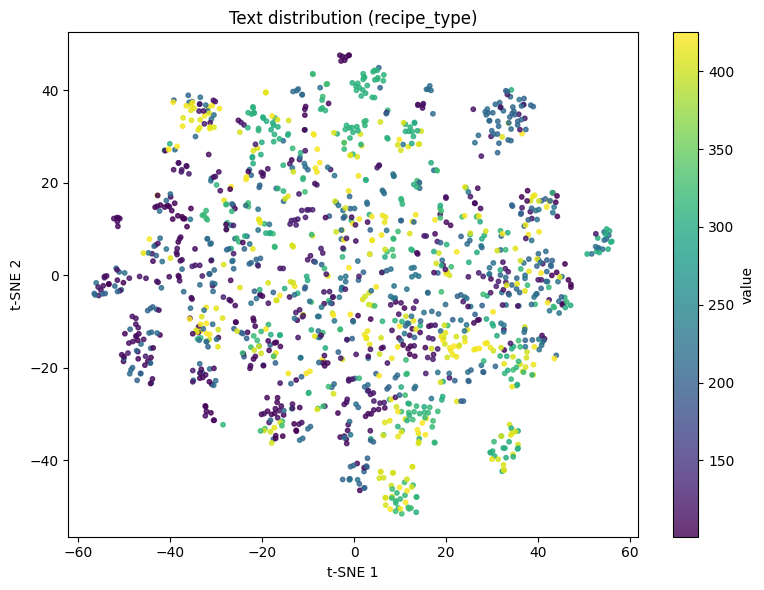

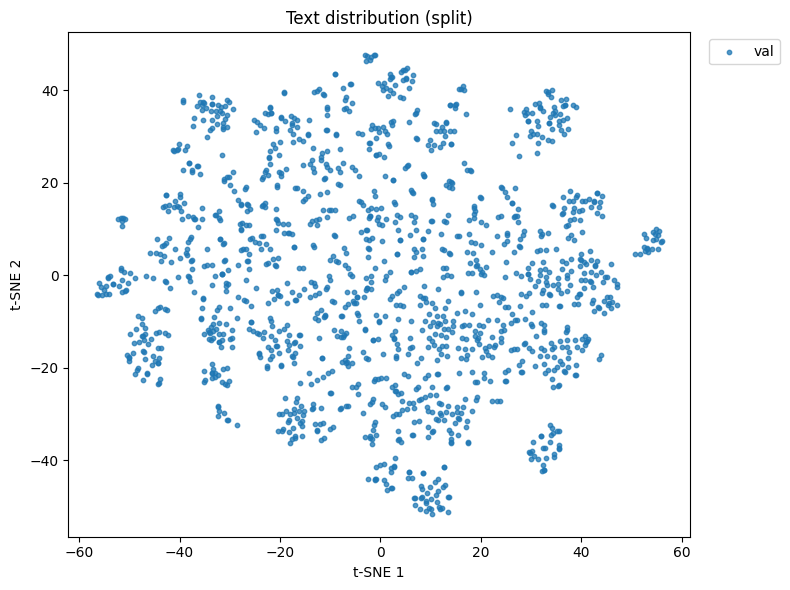

In [ ]:
Z_text = tsne_2d(X_text, perplexity=30, max_iter=1500)
plot_tsne(Z_text, labels=df_ok["recipe_type"], title="Text distribution (recipe_type)")
plot_tsne(Z_text, labels=df_ok["split"], title="Text distribution (split)")

# Samples

,id,split,recipe_type,sentence,segment,video_path,video_url
1180,c00gy-NVzaw_6,val,421,shape the dough fill it and seal the edges,[202. 223.],val/c00gy-NVzaw_6.mp4,https://www.youtube.com/watch?v=c00gy-NVzaw
58,ulrh6C5V_VI_6,val,303,season with some salt green leek and sesame oil,[137. 156.],val/ulrh6C5V_VI_6.mp4,https://www.youtube.com/watch?v=ulrh6C5V_VI
1039,xhXcJ6bhX2w_4,val,106,incorporate salt and pepper mix it and add bea...,[128. 151.],val/xhXcJ6bhX2w_4.mp4,https://www.youtube.com/watch?v=xhXcJ6bhX2w
751,Ky0zf0v2F5A_3,val,422,add diced cooked chicken to the pot,[105. 110.],val/Ky0zf0v2F5A_3.webm,https://www.youtube.com/watch?v=Ky0zf0v2F5A
1121,AMBH5L6x3dQ_1,val,423,add soaked cashew nuts to the processor,[39. 57.],val/AMBH5L6x3dQ_1.mp4,https://www.youtube.com/watch?v=AMBH5L6x3dQ
185,RnSl1LVrItI_6,val,325,cut the cilantro and lime,[291. 331.],val/RnSl1LVrItI_6.mp4,https://www.youtube.com/watch?v=RnSl1LVrItI
167,IDu5czNIM1w_5,val,114,add butter grated parmesan cheese chopped chiv...,[105. 125.],val/IDu5czNIM1w_5.mp4,https://www.youtube.com/watch?v=IDu5czNIM1w
1046,fnbXolhuE7k_1,val,416,add the lentils to the pressure cooker,[124. 141.],val/fnbXolhuE7k_1.mp4,https://www.youtube.com/watch?v=fnbXolhuE7k
249,DpuofwnCI8A_6,val,418,add the mashed chick peas and the whole chick ...,[438. 481.],val/DpuofwnCI8A_6.mp4,https://www.youtube.com/watch?v=DpuofwnCI8A
977,lwdypoLpMW4_1,val,225,add the garlic and beans to the pot,[169. 187.],val/lwdypoLpMW4_1.webm,https://www.youtube.com/watch?v=lwdypoLpMW4


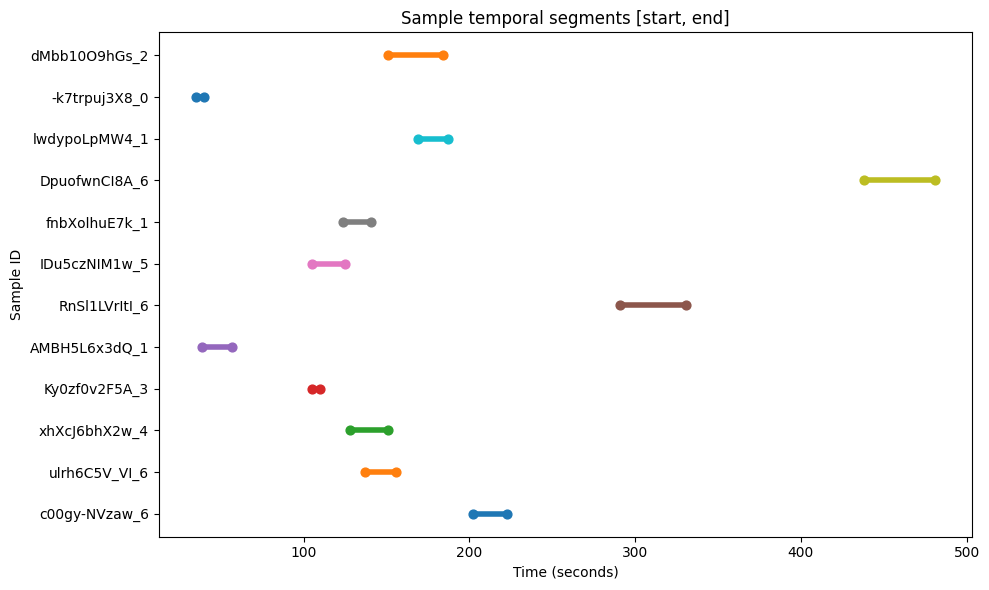

In [ ]:
visualize_samples(df_ok, n=12, random_state=7)

# Input Distribution

pca_dim= 50


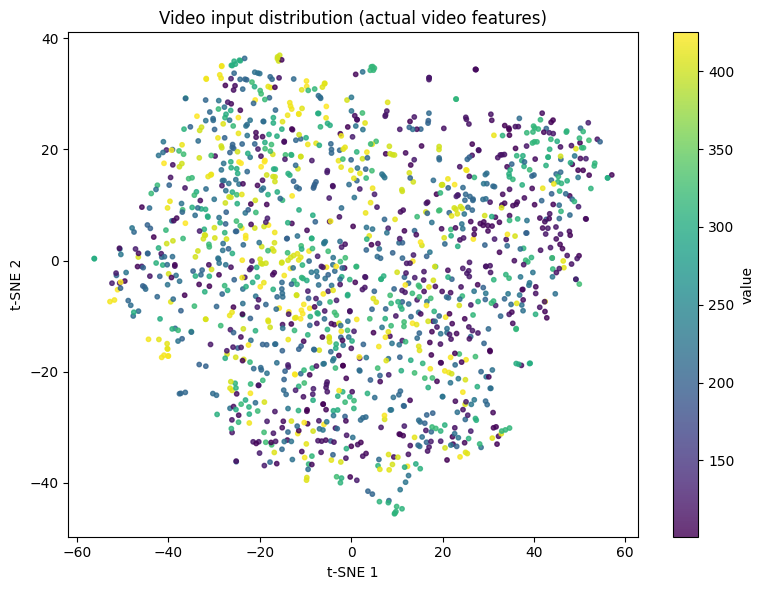

pca_dim= 50


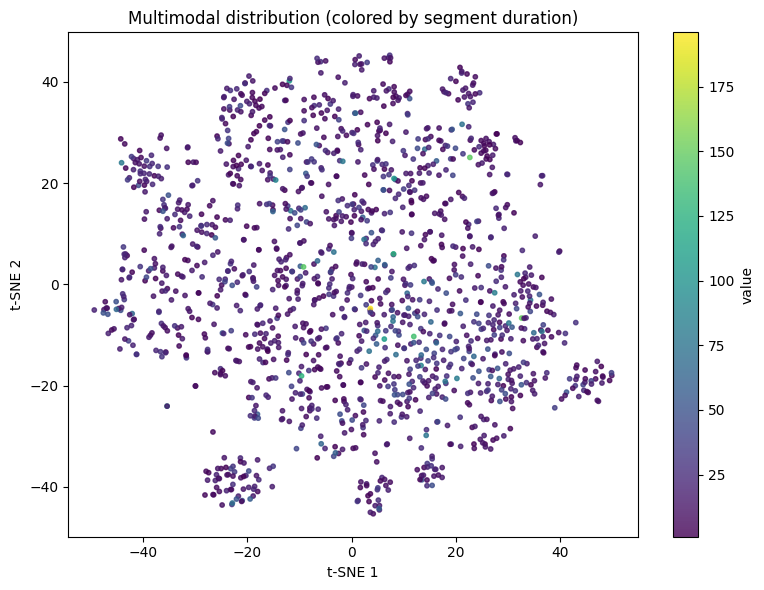

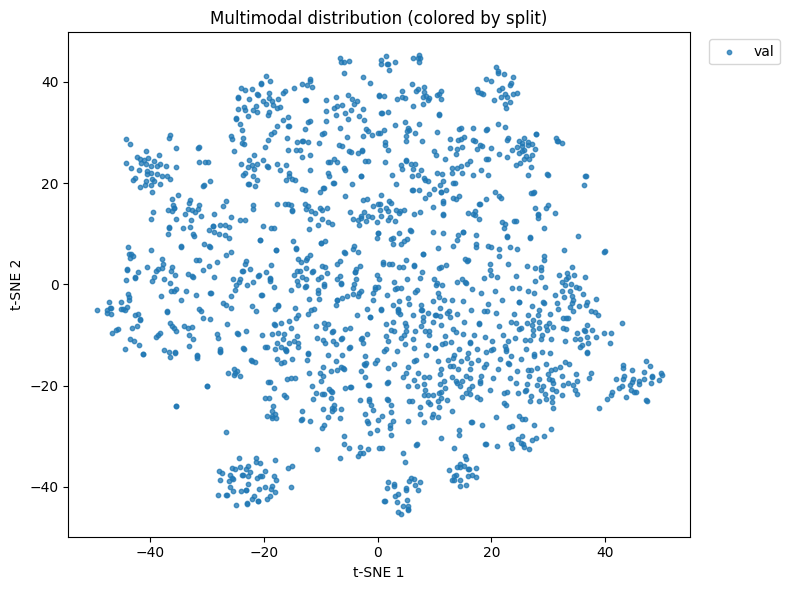

In [ ]:
Z_video = tsne_2d(X_video, perplexity=30, max_iter=1500)
plot_tsne(Z_video, labels=df_ok["recipe_type"], title="Video input distribution (actual video features)")

Z_mm = tsne_2d(X_mm, perplexity=35, max_iter=2000)
plot_tsne(Z_mm, labels=df_ok["seg_duration"], title="Multimodal distribution (colored by segment duration)")
plot_tsne(Z_mm, labels=df_ok["split"], title="Multimodal distribution (colored by split)")


(20 pts)

Now let's consider what evaluation metrics you would want to use in training and validation. Answer the following:

1. What evalution metrics are you planning on using? Why?
2. Are there any other metrics that could be used here or that you considered?
3. List out the pros and cons of the evaluation metrics you decided to go with.

In addition, code up functions that calculate the metric. We have provided a template to start with. This will be used later for when we do start training models, so take some time in designing this!

**Answer in separate writeup doc**

In [ ]:
# Accuracy as an example
def evaluation_metric(predictions, ground_truths):
  num_correct = 0
  num_tot = 0

  for prediction, truth in zip(predictions, ground_truths):
    if prediction == truth:
      num_correct += 1
    num_tot += 1

  if num_tot == 0:
    raise ValueError("Issue reading ground truths/No ground truths provided!")

  return num_correct / num_tot


In [ ]:
EPS = 1e-12

def _fix_segment(seg):
    """ensure [start, end] in correct order as floats"""
    if len(seg) != 2:
        raise ValueError(f"Segment must be length 2, got {seg}")

    s, e = float(seg[0]), float(seg[1])
    if s > e:
        s, e = e, s
    return s, e

def temporal_iou(pred_seg, gt_seg):
    """IoU for one predicted segment and one ground-truth segment."""
    ps, pe = _fix_segment(pred_seg)
    gs, ge = _fix_segment(gt_seg)

    inter = max(0.0, min(pe, ge) - max(ps, gs))
    union = max(pe, ge) - min(ps, gs)
    if union <= 0:
        return 0.0
    return inter / (union + EPS)

def evaluate_key3(predictions, ground_truths):
    """
    predictions: list/array of [start, end]
    ground_truths: list/array of [start, end]

    returns dict with these 3 metrics:
      - mIoU
      - R@1_IoU@0.5
      - R@1_IoU@0.7
    """
    if len(predictions) != len(ground_truths):
        raise ValueError("predictions and ground_truths must have same length")
    if len(predictions) == 0:
        raise ValueError("No samples provided")

    ious = np.array([temporal_iou(p, g) for p, g in zip(predictions, ground_truths)], dtype=np.float64)

    metrics = {
        "mIoU": float(np.mean(ious)),
        "R@1_IoU@0.5": float(np.mean(ious >= 0.5)),
        "R@1_IoU@0.7": float(np.mean(ious >= 0.7)),
    }
    return metrics


In [ ]:
preds = [[47, 61], [65, 90], [90, 100]]
gts   = [[47, 60], [67, 89], [91, 98]]

print(evaluate_key3(preds, gts))

{'mIoU': 0.836190476190419, 'R@1_IoU@0.5': 1.0, 'R@1_IoU@0.7': 0.6666666666666666}


(15 pts)

For the next part of this assignment, we are going to play around with instruction tuning. This is when you prompt the model in specifc ways to guarentee a specific output. Provide prompts that would be able to guarentee the right output based on the data.

Scenario 1: You have a dataset of reviews from restaurants, when you see this review:
"This place stinks, the service was awful and the food was not cooked. I will never come back here!"
Provide a prompt that would have the model return the sentiment of the review, which is negative.

Scenario 2: You are looking through a dataset of angry, sad, and happy faces. Provide a prompt that would get the emotion a person is expressing.

Scenario 3: A dataset of novels, with the following paragraph:
"The man, Edgar, flew to Italy to hike the Alps. He was looking forward to going skiing there."

Provide prompts to get the name of the subject, where they are going, and what they were planning to do.

**Answer in separate writeup doc**

## Bonus

**As a bonus part of this assignment (10 points of extra credit)**, we welcome you to do the following: Create a project where you create a dataset (separate from the one you will be using for the rest of the HWs) and train some models on the dataset. For the bonus credit, explain what goal you went with, the model you decided to use, and the evalutaion metrics used. Explain your reasoning for each of the choices. Be as creative as possible!

Here is what we are looking for:
* What is the task you are looking to do
* What dataset you are using
* The modalities you will extract
* What model you will be using
* The evaluation metrics you employ
* Results from training adn testing using the evaluation metrics

Be sure to provide a rationale for each design choice!



In [ ]:
# BONUS CODE IN SEPARATE COLAB

**I created the bonus in a separate notebook. That notebook will also be attached as a pdf after this.**

(5 pts)

Now, let's take some time to reflect. We have dug deep into the data collection and process portion of machine learning. Take some time to discuss:

1. The most interesting topic discussed in this homework assignment.
2. A challenging aspect that you did not expect to deal with and what insights you used to address it.
3. How you feel about the overall quality of your dataset? Is there anything lacking? What is particularly great about it?

There is no specific right answer we are looking for, answer how you think!

**Answer in separate doc**